## Tutorial for Applying SoccerCPD to kloppy Data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import rpy2.robjects as robjects
import rpy2.robjects.packages as rpackages

from src.match import Match
from src.kloppy import Kloppy
from src.soccercpd import SoccerCPD

In [2]:
# robjects.r(".libPaths('/usr/lib/R/site-library')")
utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)
if not rpackages.isinstalled('gSeg'):
    utils.install_packages('gSeg')
rpackages.importr('gSeg')

rpy2.robjects.packages.Package as a <module 'gSeg'>

### Converting preprocessed RGP data into SoccerCPD format

In [3]:
matches = pd.read_csv("data/matches.csv", index_col=0, header=0, encoding="utf-8-sig")
matches

,home_id,home_name,away_id,away_name
1,0,NaN,82455,제주 유나이티드
2,82461,로아소 구마모토,82494,울산 HD
3,0,NaN,0,NaN
4,0,NaN,82535,포항 스틸러스
5,82602,제주 유나이티드,82581,포항 스틸러스
6,0,NaN,0,NaN
7,82577,PVF 아카데미,0,NaN
8,82597,로아소 구마모토,0,NaN
9,82735,울산 HD,0,NaN
10,0,NaN,0,NaN


In [4]:
match_index = 1
home_away = "home"  # Choose either home or away
home_id = matches.at[match_index, "home_id"]
away_id = matches.at[match_index, "away_id"]
col_dict = {"index": "frame_id", "session": "period_id", "time": "timestamp"}

if away_id == 0:
    home_away = "home"
    col_dict["phase"] = "home_phase"
    data = pd.read_csv(f"data/kloppy/{home_id}.csv", header=0, parse_dates=["datetime"])
elif home_id == 0:
    home_away = "away"
    col_dict["phase"] = "away_phase"
    data = pd.read_csv(f"data/kloppy/{away_id}.csv", header=0, parse_dates=["datetime"])
else:
    data = pd.read_csv(f"data/kloppy/{home_id}-{away_id}.csv", header=0, parse_dates=["datetime"])
    
data = data.reset_index().rename(columns=col_dict)
data

,frame_id,datetime,period_id,timestamp,away_phase,away_02_x,away_02_y,away_02_speed,away_03_x,away_03_y,...,away_30_speed,away_34_x,away_34_y,away_34_speed,away_36_x,away_36_y,away_36_speed,away_37_x,away_37_y,away_37_speed
0,0,2024-10-21 02:30:00.000,1,0.0,1,22.700346,-6.629182,2.164,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-10-21 02:30:00.100,1,0.1,1,22.683823,-6.573528,1.882,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2024-10-21 02:30:00.200,1,0.2,1,22.683823,-6.531789,1.591,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2024-10-21 02:30:00.300,1,0.3,1,22.683823,-6.476136,2.034,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2024-10-21 02:30:00.400,1,0.4,1,22.716867,-6.406569,2.530,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43195,43195,2024-10-21 03:56:59.500,2,2219.5,3,-6.742497,-29.530334,1.319,NaN,NaN,...,2.057,NaN,NaN,NaN,-8.642570,-30.629472,2.383,-9.914794,-31.172083,3.735
43196,43196,2024-10-21 03:56:59.600,2,2219.6,3,-6.709452,-29.558160,1.682,NaN,NaN,...,3.250,NaN,NaN,NaN,-8.559958,-30.657299,2.653,-9.815659,-31.144257,3.955
43197,43197,2024-10-21 03:56:59.700,2,2219.7,3,-6.676407,-29.572073,1.823,NaN,NaN,...,1.687,NaN,NaN,NaN,-8.510391,-30.699039,2.744,-9.733047,-31.130344,3.495
43198,43198,2024-10-21 03:56:59.800,2,2219.8,3,-6.643363,-29.572074,1.538,NaN,NaN,...,1.879,NaN,NaN,NaN,-8.460824,-30.726865,2.340,-9.633913,-31.130344,3.331


In [5]:
kloppy = Kloppy(data)
kloppy.rotate_pitch()
input_data = kloppy.convert_to_soccercpd_input(exclude_gks=False)
input_data

,datetime,team,player_id,player_period,session,time,x,y,speed
0,2024-10-21 02:30:00.000,away,2,1,1,0.0,-22.700346,6.629182,2.164
1,2024-10-21 02:30:00.100,away,2,1,1,0.1,-22.683823,6.573528,1.882
2,2024-10-21 02:30:00.200,away,2,1,1,0.2,-22.683823,6.531789,1.591
3,2024-10-21 02:30:00.300,away,2,1,1,0.3,-22.683823,6.476136,2.034
4,2024-10-21 02:30:00.400,away,2,1,1,0.4,-22.716867,6.406569,2.530
...,...,...,...,...,...,...,...,...,...
43195,2024-10-21 03:56:59.500,away,37,3,2,2219.5,-9.914794,-31.172083,3.735
43196,2024-10-21 03:56:59.600,away,37,3,2,2219.6,-9.815659,-31.144257,3.955
43197,2024-10-21 03:56:59.700,away,37,3,2,2219.7,-9.733047,-31.130344,3.495
43198,2024-10-21 03:56:59.800,away,37,3,2,2219.8,-9.633913,-31.130344,3.331


### Converting kloppy data into SoccerCPD format

In [ ]:
data = pd.read_pickle("data/kloppy/sample_kloppy_file.pkl")
data

In [ ]:
kloppy = Kloppy(data)
kloppy.preprocess_times()
kloppy.round_change_times()
kloppy.label_player_periods()
input_data = kloppy.convert_to_soccercpd_input()
input_data

### Formation detection per team

In [6]:
# home_away = "home"  # Choose either home or away
team_data = input_data[input_data["team"] == home_away]
cpd = SoccerCPD(team_data)
cpd.run()


------------------------ Subsession 1 ------------------------
               session            start_dt              end_dt
player_period                                                 
1                    1 2024-10-21 02:30:00 2024-10-21 03:05:00

* Step 1: Frame-by-frame role assignment using RoleRep
- Cost after iteration 1: 5.750
- Cost after iteration 2: 5.714
- Cost after iteration 3: 5.713
Iteration finished since there are no significant changes.

* Step 2: FormCPD based on role-adjacency matrices
Applying g-segmentation to the sequence between 02:30:00 and 03:04:59...
Generalized edge-count statistic (a) : 
  Estimated change-point location: 1500 
  Test statistic: 1084.112 
  Approximated p-value: 4.077864e-233 
Generalized edge-count statistic (u) : 
  Estimated change-point location: 215 
  Test statistic: 1998.927 
  Approximated p-value: 0 
Change-point insignificant: The formation is not changed.

Detected formation change-points:
[]

* Step 3: RoleCPD per formation

### Label assignment using precomputed formation clusters

In [11]:
benchmark_forms = pd.read_pickle("data/benchmark_forms.pkl")
benchmark_roles = pd.read_csv("data/benchmark_roles.csv", header=0)
cpd.label_roles(benchmark_roles, benchmark_forms)

# form_labels = {1: "4231", 2: "442"}
# cpd.label_roles(benchmark_roles, form_labels=form_labels)
cpd.role_labels

,1,2,3,4,5,6,7,8,9,10
1,LCB,RCM,LB,RB,RCB,CDM,LM,CF,LCM,RM
2,LCB,RCM,LB,RB,RCB,CDM,LM,CF,LCM,RM


### Saving results and visualization

In [17]:
activity_id = home_id if home_away == "home" else away_id
roster = pd.read_csv(f"data/roster/{activity_id}.csv", index_col=0, header=0)
# cpd.save_results(match_id=activity_id)
cpd.visualize(roster, role_labels=cpd.role_labels, save_dir=f"results/{activity_id}")

Successfully saved in 'results/82455/timeline.png'.


### Calculating and visualizing stats per player-role pair

In [18]:
match = Match(cpd.data, cpd.role_summary, id=activity_id)
match.compute_stats(save=True)

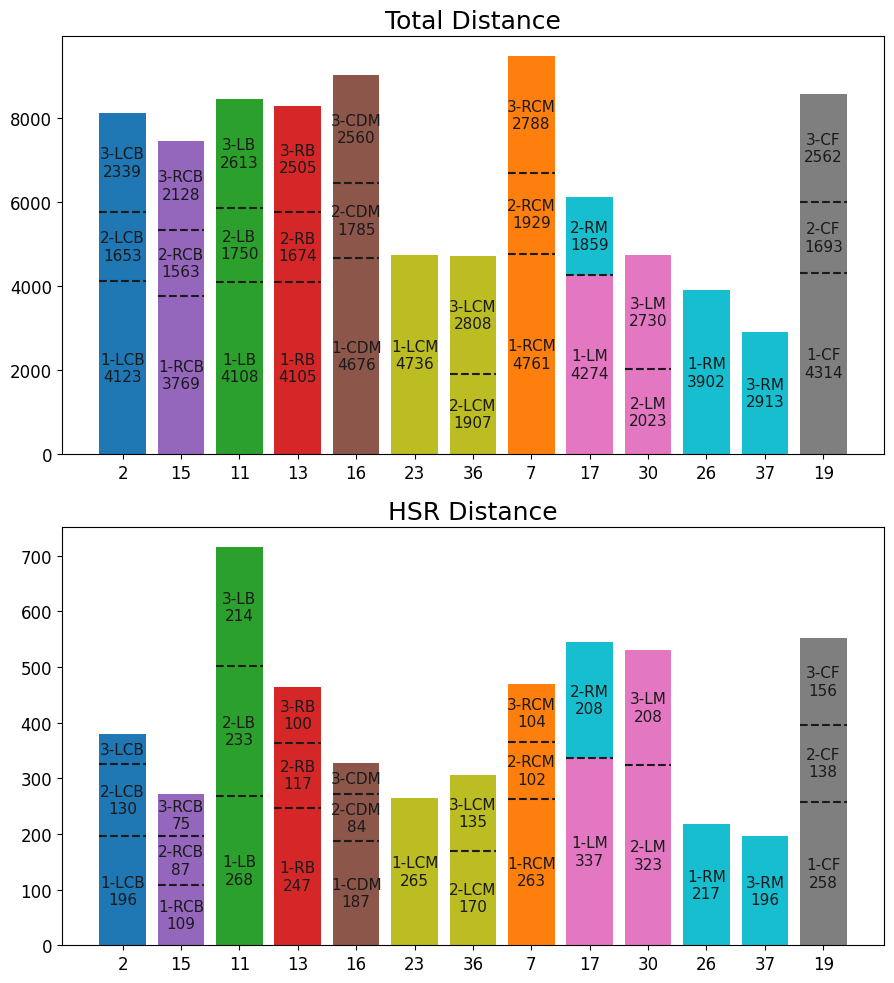

In [42]:
match.plot_by_player(save=True)

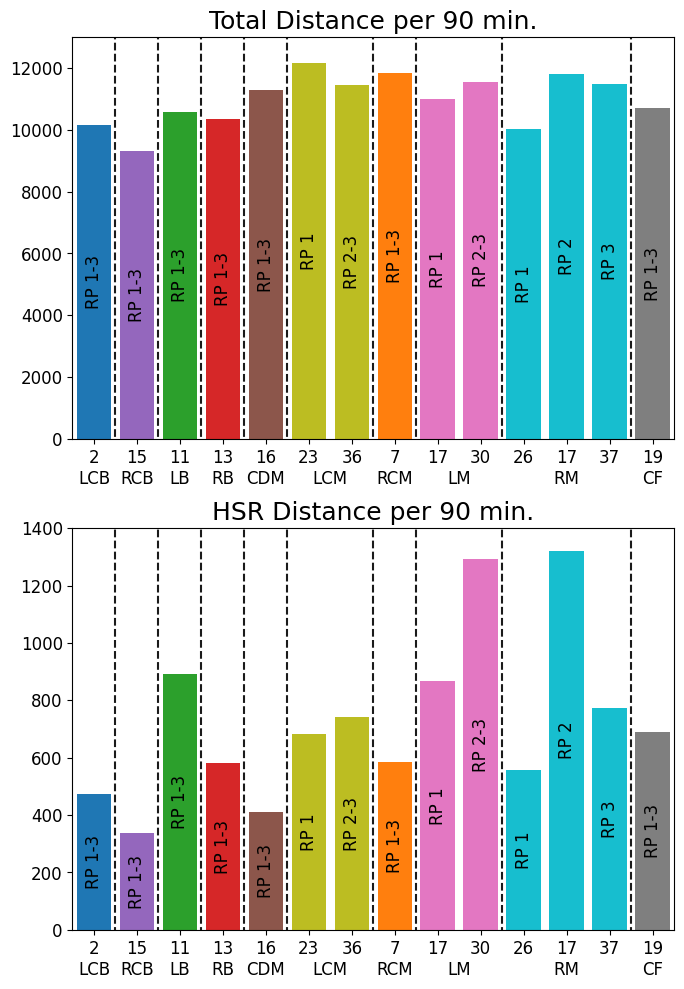

In [37]:
match.compute_role_stats()
match.plot_by_role(save=True)